In [1]:
import sys
import os
 
# Add project root to Python path
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/scaled.csv")
df.head()

,TransactionID,TransactionAmount,TransactionDate,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TimeSincePrev,AmountBalanceRatio,...,Channel_Branch,Channel_Online,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student,AccountID_freq,DeviceID_freq,IP Address_freq,MerchantID_freq,Location_freq
0,TX000001,-0.971275,2023-04-11 16:29:14,1.423718,-0.552443,-0.206794,-0.000537,2024-11-04 08:08:08,-0.800762,-0.386493,...,False,False,False,False,False,0.394950,0.780834,-1.059021,1.141666,-0.028446
1,TX000002,0.269440,2023-06-27 16:44:19,1.311287,0.305314,-0.206794,2.216472,2024-11-04 08:09:35,-0.076706,-0.338188,...,False,False,False,False,False,0.394950,0.235683,-0.568379,0.168981,0.598373
2,TX000003,-0.586882,2023-07-10 18:16:08,-1.443277,-0.909842,-0.206794,-1.023534,2024-11-04 08:07:04,0.046138,-0.171040,...,False,True,False,False,True,-0.936152,0.235683,0.903547,0.752592,0.284963
3,TX000004,-0.387456,2023-05-05 16:32:11,-1.049768,-1.353017,-0.206794,0.885797,2024-11-04 08:09:06,-0.575097,-0.349611,...,False,True,False,False,True,0.838651,0.780834,1.394189,0.947129,-0.028446
4,TX000005,-0.973468,2023-10-16 17:51:24,-1.049768,1.120184,-0.206794,0.593589,2024-11-04 08:06:39,0.967391,-0.388350,...,False,True,False,False,True,-0.048751,-0.854621,-0.568379,0.947129,0.284963


In [3]:
df = pd.read_csv("../data/processed/scaled.csv")

# Drop non-numeric columns
df = df.drop(columns=[
    "TransactionID",
    "TransactionDate",
    "PreviousTransactionDate"
], errors="ignore")

# Keep only numeric columns
df_numeric = df.select_dtypes(include=["int64", "float64", "bool"])

# Convert bool → int
df_numeric = df_numeric.astype(float)


In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(df)

print("Original shape:", df.shape)
print("PCA shape:", X_pca.shape)


Original shape: (2512, 20)
PCA shape: (2512, 14)


In [5]:
from src.clustering.hierarchical import HierarchicalClustering

hc = HierarchicalClustering(n_clusters=3, linkage_method="ward")
labels_hc = hc.fit(X_pca)


In [6]:
hc.plot_clusters(X_pca)

[INFO] Cluster plot saved to: ../results/hierarchical\hierarchical_ward_k3.png


In [7]:
hc.plot_dendrogram(X_pca)

[INFO] Dendrogram saved to: ../results/hierarchical\dendrogram_ward.png


In [ ]:
labels_hc = hc.labels_

In [9]:
import numpy as np
import pandas as pd

unique, counts = np.unique(labels_hc, return_counts=True)
cluster_sizes = dict(zip(unique, counts))

cluster_sizes

{np.int64(0): np.int64(850),
 np.int64(1): np.int64(122),
 np.int64(2): np.int64(1540)}

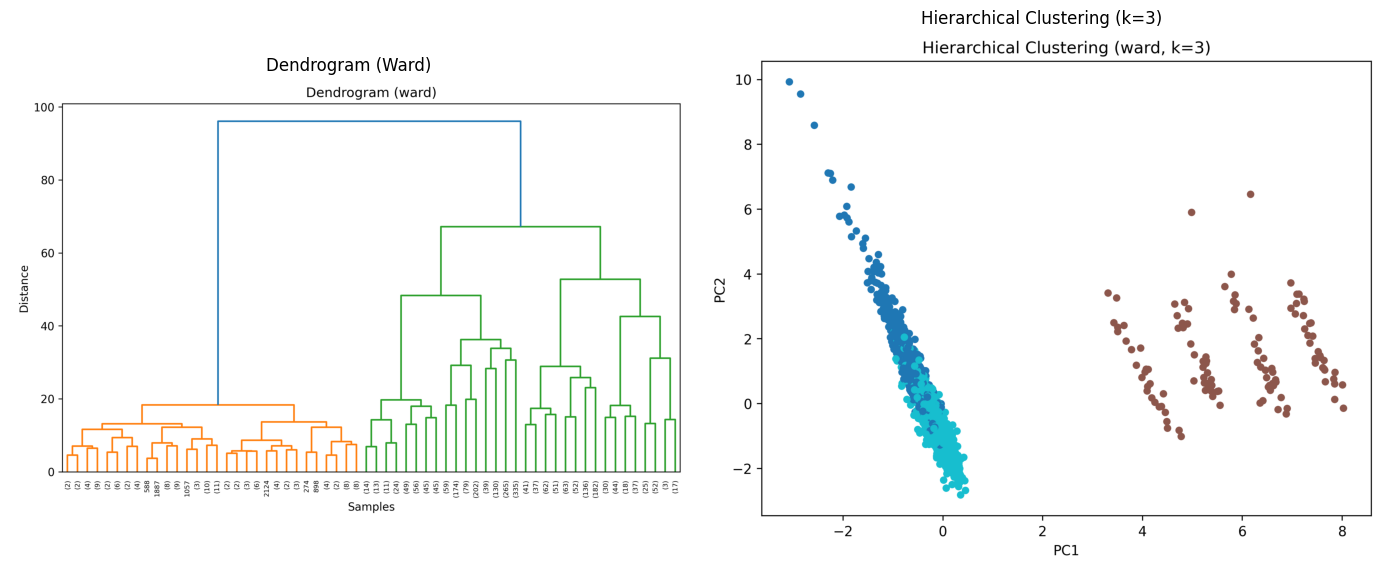

In [32]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Dendrogram
img1 = mpimg.imread("../results/hierarchical/dendrogram_ward.png")
axes[0].imshow(img1)
axes[0].axis("off")
axes[0].set_title("Dendrogram (Ward)")

# Right: Cluster Plot
img2 = mpimg.imread("../results/hierarchical/hierarchical_ward_k3.png")
axes[1].imshow(img2)
axes[1].axis("off")
axes[1].set_title("Hierarchical Clustering (k=3)")

plt.tight_layout()
plt.show()


## 📌 Hierarchical Clustering Anomaly Analysis (Cluster Size Method)

Hierarchical clustering using Ward linkage produced three clusters with the following sizes:

- **Cluster 2:** 1540 points  
- **Cluster 0:** 850 points  
- **Cluster 1:** 122 points  

The total dataset size is **2512** points. A common rule in density-based anomaly detection is to treat clusters smaller than **5% of the dataset** as anomaly clusters.

- 5% threshold = 0.05 × 2512 = **125.6**

Since **Cluster 1 contains only 122 points**, which is below the threshold, it is identified as a **small-cluster anomaly group**.

### ✔ Interpretation
- **Cluster 1** represents rare or unusual behavior in the dataset.  
- **Clusters 0 and 2** represent the dominant, normal structure of the data.  
- All points in **Cluster 1** are considered **anomalies** under the small-cluster anomaly rule.